# CILC method

After having implemented the ILC method properly and checking that it is not enough to extract the $\mu$-distorted $y$ signal, I am taking a step further by $\textit{constraining}$ the ILC method, so now I will proceed with the CILC method.

This code must

1. Calculate the covariance matrix: $$ \widehat{\mathbf{R}}_{ij}(\bar{\ell}) = \frac{1}{N_{\bar{\ell}}} \sum_{\bar{\ell} - \Delta \bar{\ell}}^{\bar{\ell} + \Delta \bar{\ell}} \sum_{m} x_{\ell m, i} x_{\ell m, j}^{*} , $$
where $N_{\ell} = (\ell + \Delta \ell + 1)^2 - (\ell - \Delta \ell)^2$.


2. Compute the transposed weights: $$\underline{\omega^t} = \frac{(\underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) \cdot \underline{a^t} \cdot \underline{\underline{\widehat{R}^{-1}}} - (\underline{a^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) \cdot \underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} }{ (\underline{a^t} \cdot {\underline{\underline{\widehat{R}^{-1}}}} \cdot \underline{a}) (\underline{b^t} \cdot \underline{\underline{\widehat{R}^{-1}}} \cdot \underline{b}) - (\underline{a^t} \cdot {\underline{\underline{\widehat{R}^{-1}}}} \cdot \underline{b})^2 } $$

3. Apply the weights ($\underline{\omega^t}$) to the data ($d_i$).

---
Shouldn't we transpose $\underline{\omega^t}$ in order to apply it to the weights?
---
---

4. Get the output: $$\hat{y} = \Sigma_i \left( \omega_i \cdot d_i (p) \right), $$
and multiply it by $\mu$.

5. Marginalise over the $\widehat{\mu y}$ tSZ signal so that:
$$ <\widehat{\mu y}>^2 \text{is minimum,}$$
$$ \tilde{\underline{w^t}} \cdot \underline{h} = 1,$$
$$ \tilde{\underline{w^t}} \cdot \underline{g} = 0.$$

### Previous

In [1]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

import gc
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *

from astropy.wcs import WCS
from reproject import reproject_from_healpix

In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel
if 'residuals_harmonic' in locals():
    del residuals_harmonic
if 'residuals_pixel' in locals():
    del residuals_pixel

gc.collect() # Manually trigger memory cleanup

1419

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Reference noise
base_sensitivity_uk_arcmin = 30.0

# Theoretical (LCDM) mu-distortion value
mu = 2e-8

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

### Pipeline

In [4]:
### 1. Load the processed Maps and the data_cube ###

path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'

print("Loading the y_map, cmb_map and data_cube (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...")

# A. Load the Data Cube (The 'Observed' (simulated) data)
data_cube = hp.read_map(path_to_websky + "data_cube_9freq.fits", field=None).astype(np.float64)

# B. Load the Truth Maps (For validation and residuals)
y_map = hp.read_map(path_to_websky + "y_map.fits").astype(np.float64)
cmb_map = hp.read_map(path_to_websky + "cmb_map.fits").astype(np.float64)

print(f"Data Cube loaded. Shape: {data_cube.shape}")
print(f"{data_cube.shape[0]} frequencies: {frequencies} with 4 layer maps of {data_cube.shape[1]} pixels as Nside = {nside_work}.")
# Should be (9, 50331648) for Nside 2048

Loading the y_map, cmb_map and data_cube (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...
Data Cube loaded. Shape: (9, 50331648)
9 frequencies: [30, 44, 70, 100, 143, 217, 353, 545, 857] with 4 layer maps of 50331648 pixels as Nside = 2048.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

## CILC

### Outline 

1. CILC method definition: Pixel CILC (P-CILC) & Harmonic CILC (H-CILC).

2. Processing for each signal:

| **Subsection** | __Signal__ | **SED** | **Extracted map** |
| :---: | :---: | :---: | :---: |
| 2.1. | tSZ | $g(\nu) = x \coth \left( \frac{x}{2} \right) - 4 $ | $y$-map |
| 2.2. | CMB | $a=[1,...,1]$ | $CMB$-map |
| 2.3. | $\mu$-distorted tSZ | $h(\nu) = - \frac{x}{2} \frac{1}{\sinh^2\left( \frac{x}{2} \right)}$ | $\mu y$-map |

3. Plotting two views for every map:
- Zoomed view.
- Mollweide view.

## 1. CILC method definition

### Old ILC definitions

In [ ]:
def run_pixel_ilc(data_cube, g_vector_muK): ### UNITLESS MAP OUTPUT + WEIGHTS ###

    # C definition
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T) # IS IT THAT d_i (p') * d_j (p') = data_cube @ data_cube.T
    C_inv = np.linalg.pinv(C)

    # Calculate the weights
    weights = (C_inv @ g_vector_muK) / (g_vector_muK.T @ C_inv @ g_vector_muK)

    return weights @ data_cube, weights

# weights @ data_cube IS UNITLESS AS [weights] = 1/g^t * data_cube = 1/T_cmb * T_cmb
# [g] = T_cmb_muK
# [data_cube] = T_cmb_muK

In [ ]:
def run_harmonic_ilc_with_weights(data_cube, g_vector_muK, l_bins): ### UNITLESS MAP OUTPUT + WEIGHTS PER BIN  ###
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ g_vector_muK) / (g_vector_muK.T @ inv_cov @ g_vector_muK)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

### New CILC definitions

In [6]:
def run_pixel_cilc(data_cube, seds_to_constrain, target_responses):
    """
    Generalized Pixel-Space CILC.
    - data_cube: (n_freq, n_pix)
    - seds_to_constrain: list of vectors [sed1, sed2, ...]
    - target_responses: list of values [resp1, resp2, ...] (e.g., [1, 0, 0])
    """
    n_freq, n_pix = data_cube.shape
    
    # 1. Compute Covariance Matrix R
    # Using float64 for the inversion to avoid precision errors with weak signals
    R = (1.0 / n_pix) * (data_cube.astype(np.float64) @ data_cube.T.astype(np.float64))
    R_inv = np.linalg.pinv(R)

    # 2. Define Constraint Matrix A and target vector e
    A = np.column_stack(seds_to_constrain) # Shape (n_freq, n_constraints)
    e = np.array(target_responses)         # Shape (n_constraints,)

    # 3. Calculate CILC weights
    # w = R_inv * A * (A^T * R_inv * A)^-1 * e
    A_invR_A = A.T @ R_inv @ A
    weights = R_inv @ A @ np.linalg.inv(A_invR_A) @ e
    
    # 4. Apply weights to get the unitless map
    map_out = weights @ data_cube
    
    return map_out, weights

In [11]:
def run_harmonic_cilc_with_weigths(data_cube, seds_to_constrain, target_responses, l_bins):
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    
    # Transform to Harmonic Space
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    A = np.column_stack(seds_to_constrain)
    e = np.array(target_responses)
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        
        # 1. Covariance per bin
        # R_ij = sum(alm_i * conj(alm_j)) / N_modes
        R_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        R_inv = np.linalg.pinv(R_bin)
        
        # 2. Weights for this scale
        A_invR_A = A.T @ R_inv @ A
        w_bin = R_inv @ A @ np.linalg.inv(A_invR_A) @ e
        
        weights_per_bin.append(w_bin)
        final_alms[mask] = w_bin @ bin_alms
        
    map_out = hp.alm2map(final_alms, nside=nside)
    return map_out, np.array(weights_per_bin)

## 2. CILC implementation

In [13]:
### Define the mixing vectors (SEDs) in muK: g_vector_muK, h_vector_muK, a_cmb_muK ###

# Define g_vector and h_vector in muK units for the frequencies in the data cube
# Mixing vectors (SEDs) in muK
g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K
h_vector_muK = np.array([get_tsz_h(nu) for nu in frequencies]) * T_cmb_muK
a_cmb_muK = np.ones(len(frequencies)) * T_cmb_muK

In [14]:
### Check lengths of the vectors and frequencies ###
print("Length of g_vector_muK: ", len(g_vector_muK)) # Should be 9, one for each frequency
print("Length of h_vector_muK: ", len(h_vector_muK)) # Should be 9, one for each frequency
print("Length of a_cmb_muK: ", len(a_cmb_muK)) # Should be 9, one for each frequency
print("Length of frequencies: ", len(frequencies)) # Should be 9, one for each frequency

Length of g_vector_muK:  9
Length of h_vector_muK:  9
Length of a_cmb_muK:  9
Length of frequencies:  9


In [9]:
### CALL THE P-CILC METHOD FOR mu-distorted tSZ ###

# True mu-distorted tSZ signal in dimensionless units
muy_map = mu * y_map

# Constraints: 1 for mu-distortion, 0 for tSZ, 0 for CMB
seds = [h_vector_muK, g_vector_muK, a_cmb_muK]
targets = [1, 0, 0]

# Pixel CILC
muy_hat_pixel, w_pixel = run_pixel_cilc(data_cube, seds, targets)

# Calculate the residual in dimensionless mu*y units (Truth - Reconstruction)
muy_residual_pixel = muy_map - muy_hat_pixel

"""
# As y_map is also unitless, I will leave both unitless. However, I could also convert both to muK units and have a 10^5 scale factor.
muy_map_muK = muy_map * T_cmb_muK
residual_pixel_muK = muy_map_muK - muy_hat_pixel * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_pixel):.2e}")
print(f"Residual max: {np.max(muy_residual_pixel):.2e}")
print("WATCH!!! THERE IS A PROBLEM WITH RECO...")

Truth max: 3.99e-12
Reco max: 6.07e-05
Residual max: 6.17e-05
WATCH!!! THERE IS A PROBLEM WITH RECO...


In [ ]:
### A.1. PIXEL CILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_pixel, title="P-CILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_pixel, title="Residual (P-CILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/CILC/mu_y_maps/PCILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### ANALYSIS WEIGHTS FOR PIXEL CILC ###

df_weights_pixel_cilc = pd.DataFrame({
    'Freq (GHz)': frequencies,
    #'Weight': weights_pixel_ilc
    'Weight': w_pixel,
    'g(nu) * T_cmb_muK': g_vector_muK,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_cilc = df_weights_pixel_cilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- CILC Analysis Weights ---")
print(df_horizontal_pixel_cilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_cilc = np.sum(w_pixel * g_vector_muK)
w_pixel_sum = np.sum(w_pixel)
print(f"Constraint Check: {constraint_check_pixel_cilc:.4f}")
print(f"Sum of Weights: {w_pixel_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

In [ ]:
print(f"Check Mu-Preservation (should be 1): {np.dot(w_pixel, h_vector_muK):.4f}")
print(f"Check tSZ-Nulling (should be 0):     {np.dot(w_pixel, g_vector_muK):.4e}")
print(f"Check CMB-Nulling (should be 0):     {np.dot(w_pixel, a_cmb_muK):.4e}")

In [17]:
### H-ILC (with weights) ###
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

# Mathieu's paper uses these l_bins: Delta_l = 50 for l < 2075 and Delta_l = 20 for l > 2075...
l_bins_Mathieu = [2, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000,
               1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 
               1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 
               1950, 2000] + list(range(2050,2075+20,20)) + list(range(2100,3000+20,20))
"""
Si emplees aquest s'ordinador se mor, això seria per fer servir es CLUSTER
"""

seds = [h_vector_muK, g_vector_muK, a_cmb_muK]
targets = [1, 0, 0]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
y_hat_harmonic, weights_harmonic_bins = run_harmonic_cilc_with_weigths(data_cube, seds, targets, l_bins)

# Residual map in muK units for harmonic ILC
y_residual_harmonic = y_map - y_hat_harmonic


"""
Again, I could convert both to muK units and have a 10^5 scale factor, but I will leave them unitless for consistency with the pixel ILC.
y_map_muK = y_map * T_cmb_muK
residual_harmonic = y_map_muK - y_hat_harmonic * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_harmonic):.2e}")
print(f"Residual max: {np.max(y_residual_harmonic):.2e}")

Truth max: 1.99e-04
Reco max: 8.16e-06
Residual max: 2.00e-04


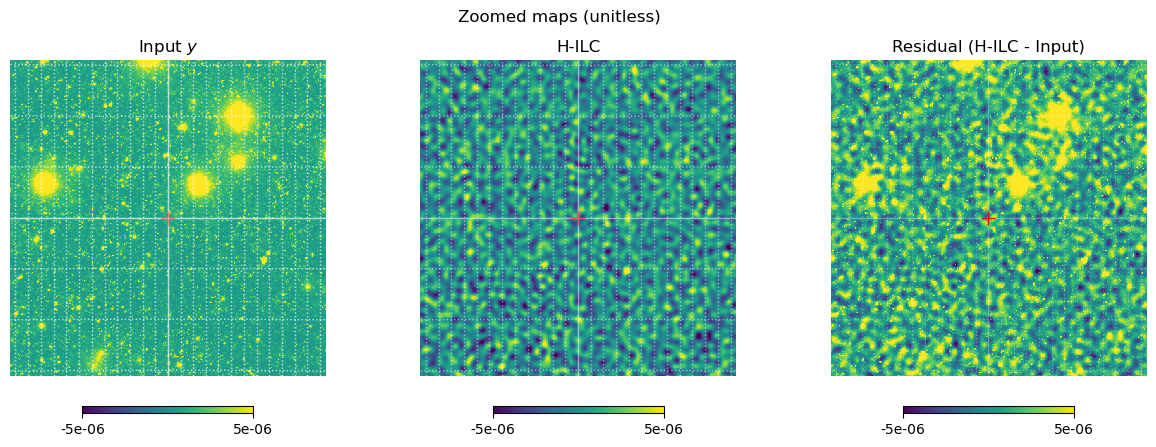

In [19]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -5*10**-6, 'max': 5*10**-6}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
#hp.gnomview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_zoom)
hp.gnomview(y_map, title="Input $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
#hp.gnomview(y_hat_harmonic_muK, title="H-ILC", **params_zoom) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.gnomview(y_hat_harmonic, title="H-ILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
#hp.gnomview(y_residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_zoom)
hp.gnomview(y_residual_harmonic, title="Residual (H-ILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/CILC/y_maps/HILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 2.1. tSZ signal: $g(\nu) \rightarrow$ ($y$-map)

Execute both P-ILC & H-ILC methods separetly for the seek of time. Harmonic-space is more time consuming as more bins are considered.

## 3.1. P-ILC & H-ILC: $y$-maps

## 2.2. CMB signal: $a = [1,...,1] \rightarrow$ ($CMB$-map)

## 3.2. P-ILC & H-ILC: $CMB$-maps

## 2.3. $\mu$-distorted tSZ: $f(\nu) \rightarrow$ ($\mu y$-map)

## 3.3. P-ILC & H-ILC: $\mu y$-maps